In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Cargar archivo
df = pd.read_csv('ventas_bogota_limpiar.csv',
                  sep= ";",
                  encoding= 'utf-8'
                  )
df


,id_venta,fecha,producto,categoria,precio,cantidad,ciudad,metodo_pago,cliente_satisfecho
0,1,13/02/2024,Monitor r,Accesorios,1140503.31,6,Barranquilla,Tarjeta,si
1,2,29/02/2024,Audefenes,Accesorios,2786223.89,2,Barranquilla,NaN,si
2,3,5/04/2024,TeCladO,Acxexorios,958850.40,3,Cali,NaN,No
3,4,12/05/2024,Audefenes,Periféricos,1544815.40,5,Barranquilla,Efectivo,NaN
4,5,13/05/2024,Audefenes,Periféricos,NaN,9,bogotá,tarjeta,Sí
...,...,...,...,...,...,...,...,...,...
200,196,7/03/2024,TeCladO,Periféricos,1093703.74,5,BOGOTA,NaN,si
201,197,19/03/2024,TeCladO,Periféricos,2851075.64,4,NaN,Transferencia,si
202,198,10/03/2024,Laptop,Electrónica,2401288.14,8,NaN,Transferencia,NO
203,199,3/02/2024,Audefenes,Accesorios,581720.03,6,bogotá,tarjeta,NaN


In [3]:

# Limpieza básica
df["ciudad"] = (
    df["ciudad"]
    .str.strip()
    .str.title()
    .replace({"Bogota": "Bogotá"})
)

df["categoria"] = (
    df["categoria"]
    .str.strip()
    .replace({"Acxexorios": "Accesorios"})
)

df["producto"] = (
    df["producto"]
    .str.strip()
    .replace({"       Monitor    r": "Monitor"})
)

# df = df.replace({
#     'ciudad': {'NY': 'New York', 'BCN': 'Barcelona'},
#     'estado': {'A': 'Activo', 'I': 'Inactivo'}
# })

df["cliente_satisfecho"] = df["cliente_satisfecho"].str.strip().str.capitalize()
df["metodo_pago"] = df["metodo_pago"].str.strip().str.title()

# Columna de ventas
df["ventas"] = df["precio"] * df["cantidad"]

             Ingreso_Total  Unidades  Ticket_Promedio
categoria                                            
Periféricos   5.633076e+08       346     8.407576e+06
Accesorios    5.482465e+08       320     8.434562e+06
Electrónica   5.329718e+08       318     9.189170e+06


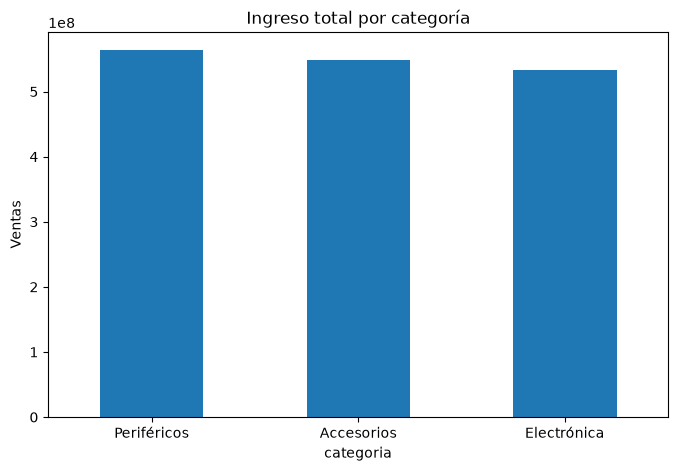

In [7]:
# 1. Ingreso por categoría
resultado1 = (
    df.groupby("categoria")
      .agg(
          Ingreso_Total=("ventas", "sum"),
          Unidades=("cantidad", "sum"),
          Ticket_Promedio=("ventas", "mean")
      )
      .sort_values("Ingreso_Total", ascending=False)
)

print(resultado1)
resultado1["Ingreso_Total"].plot(kind="bar", figsize=(8,5))
plt.title("Ingreso total por categoría")
plt.ylabel("Ventas")
plt.xticks(rotation=0)
plt.show()


              Ingreso_Total  Transacciones  Venta_Promedio
ciudad                                                    
Bogotá         7.860170e+08             92    8.543663e+06
Barranquilla   2.662134e+08             30    8.873779e+06
Medellín       2.453065e+08             28    8.760947e+06
Cali           2.393811e+08             32    7.480660e+06


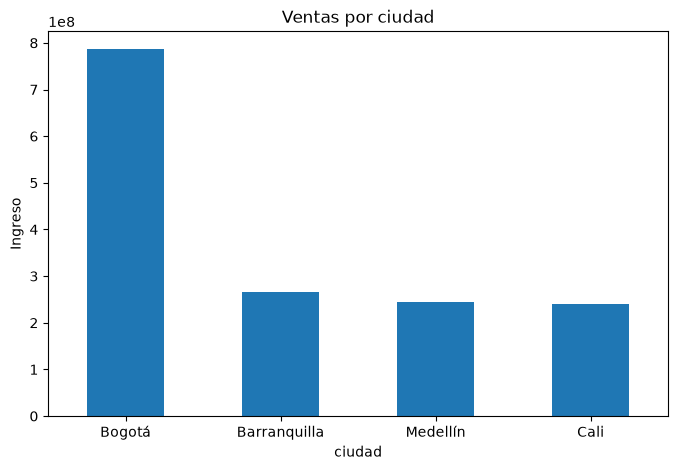

In [8]:
# 2. Desempeño por ciudad
resultado2 = (
    df.groupby("ciudad")
      .agg(
          Ingreso_Total=("ventas", "sum"),
          Transacciones=("ventas", "count"),
          Venta_Promedio=("ventas", "mean")
      )
      .sort_values("Ingreso_Total", ascending=False)
)

print(resultado2)

resultado2["Ingreso_Total"].plot(kind="bar", figsize=(8,5))
plt.title("Ventas por ciudad")
plt.ylabel("Ingreso")
plt.xticks(rotation=0)
plt.show()

              Unidades       Ingreso  Precio_Promedio
producto                                             
Laptop             205  3.956426e+08     1.897318e+06
TeCladO            190  3.538768e+08     1.867293e+06
Monitor    r       234  3.252636e+08     1.647015e+06
Audefenes          199  3.183823e+08     1.799976e+06
Mouse              156  2.513606e+08     1.701738e+06


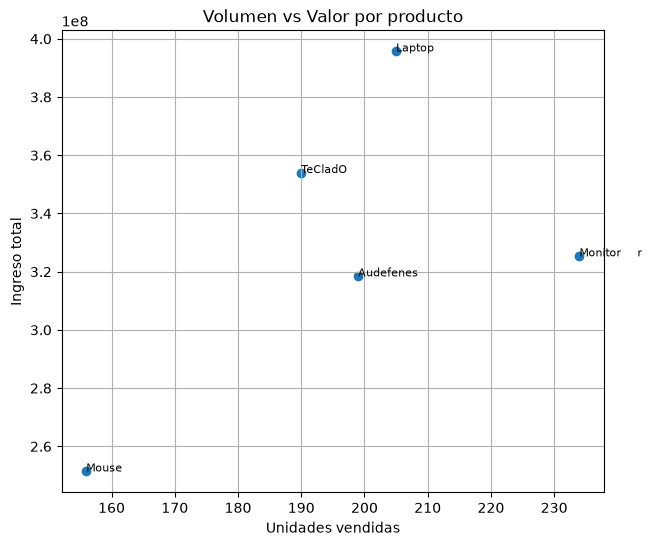

In [9]:
# 3. Productos de alto volumen vs alto valor
resultado3 = (
    df.groupby("producto")
      .agg(
          Unidades=("cantidad", "sum"),
          Ingreso=("ventas", "sum"),
          Precio_Promedio=("precio", "mean")
      )
      .sort_values("Ingreso", ascending=False)
)

print(resultado3)

plt.figure(figsize=(7,6))
plt.scatter(resultado3["Unidades"], resultado3["Ingreso"])

for producto, fila in resultado3.iterrows():
    plt.text(fila["Unidades"], fila["Ingreso"], producto, fontsize=8)

plt.xlabel("Unidades vendidas")
plt.ylabel("Ingreso total")
plt.title("Volumen vs Valor por producto")
plt.grid(True)
plt.show()

cliente_satisfecho     No     Si     Sí
metodo_pago                            
Efectivo            41.67  30.56  27.78
Tarjeta             37.70  31.15  31.15
Transferencia       53.12  18.75  28.12


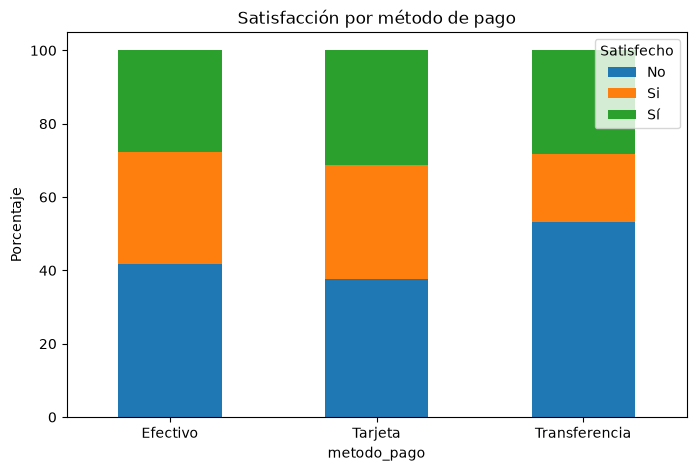

In [10]:
#4. Método de pago y satisfacción
tabla = pd.crosstab(
    df["metodo_pago"],
    df["cliente_satisfecho"],
    normalize="index"
) * 100

print(tabla.round(2))

tabla.plot(kind="bar", stacked=True, figsize=(8,5))
plt.title("Satisfacción por método de pago")
plt.ylabel("Porcentaje")
plt.legend(title="Satisfecho")
plt.xticks(rotation=0)
plt.show()

       mes        ventas  Crecimiento_%
0  2024-01  2.288759e+08            NaN
1  2024-02  3.158388e+08      37.995644
2  2024-03  2.173025e+08     -31.198276
3  2024-04  3.775833e+08      73.759257
4  2024-05  3.227376e+08     -14.525455
5  2024-06  1.821877e+08     -43.549275


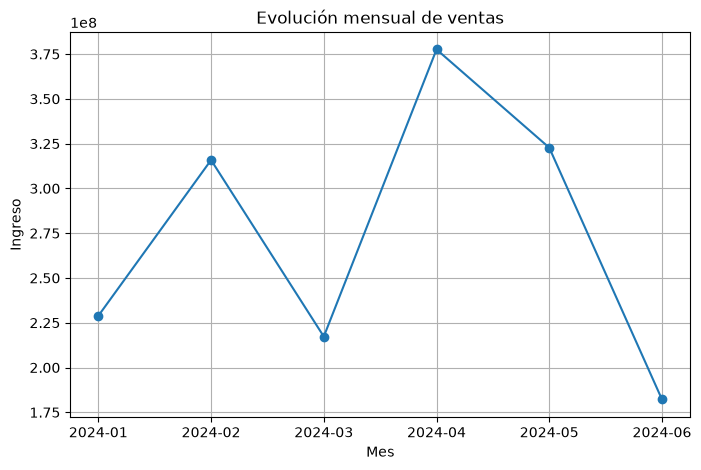

In [12]:
# 5. Tendencia mensual de ventas
df["fecha"] = pd.to_datetime(df["fecha"])
df["mes"] = df["fecha"].dt.to_period("M").astype(str)

ventas_mes = (
    df.groupby("mes")["ventas"]
      .sum()
      .reset_index()
)

ventas_mes["Crecimiento_%"] = (
    ventas_mes["ventas"].pct_change() * 100
)

print(ventas_mes)

plt.figure(figsize=(8,5))
plt.plot(ventas_mes["mes"], ventas_mes["ventas"], marker="o")
plt.title("Evolución mensual de ventas")
plt.xlabel("Mes")
plt.ylabel("Ingreso")
plt.grid(True)
plt.show()